# Ad-hoc Clustering Experiments

Interactive notebook. Edit **Section 0** only — then run sections independently.

In [16]:
import sys
import os
from pathlib import Path

# Resolve project root regardless of whether kernel cwd is notebooks/ or project root
_here = Path(os.getcwd())
_root = _here.parent if _here.name == "notebooks" else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src.preprocessing import preprocess_data, NUMERICAL_FEATURES
from src.clustering import fit_predict
from src.evaluation import evaluate_clustering
from src.utils import load_subsample_indices
from IPython.display import display

_data = _root / "data"
DATA_PATH = str(_data / "hotel_bookings_course_release_v1.csv")
SUBSAMPLE_PATH = str(_data / "subsample_indices_v1_n30000_seed12345.txt")  # set to None (Python None, not string "None") for full dataset

## 1. Single Config

Edit this cell to change the experiments within this section

In [ ]:
ALGORITHM = "ikmeans"   # "kmeans" | "ikmeans" | "gmm"
K = 4
SEED = 0               # ignored for ikmeans
FEATURE_SET = "full"   # "full" | "no_value_block" | "no_context"
SCALER = "standard"    # "standard" | "robust"
N_PCA_COMPONENTS = 2

### Load and Preprocess

In [11]:
df_full = pd.read_csv(DATA_PATH)
if SUBSAMPLE_PATH is not None:
    indices = load_subsample_indices(SUBSAMPLE_PATH)
    df = df_full.iloc[indices].reset_index(drop=True)
else:
    df = df_full.copy()

X, feature_names = preprocess_data(df, feature_set=FEATURE_SET, scaler=SCALER)

print(f"DataFrame shape : {df.shape}")
print(f"X shape         : {X.shape}")
print(f"Feature count   : {len(feature_names)}")
print(f"Features        : {feature_names}")

DataFrame shape : (30000, 32)
X shape         : (30000, 42)
Feature count   : 42
Features        : ['lead_time', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'total_of_special_requests', 'required_car_parking_spaces', 'is_repeated_guest', 'arrival_month_sin', 'arrival_month_cos', 'hotel_binary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Other', 'distribution_channel_Corporate', 'distribution_channel_Direct', 'distribution_channel_Other', 'distribution_channel_TA/TO', 'customer_type_Contract', 'customer_type_Other', 'customer_type_Transient', 'customer_type_Transient-Party', 'deposit_type_No Deposit', 'deposit_type_Non Refund', 'deposit_type_Other', 'meal_BB', 'meal_HB', 'meal_Other', 'meal_SC', 'meal_Undefined', 'reserved_room_type_A', 'reserved_room_type_B', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_t

### Fit

In [12]:
labels, model = fit_predict(X, K, SEED, ALGORITHM)

sizes = pd.Series(labels, name="size").value_counts().sort_index()
sizes.index.name = "cluster"
print(f"Algorithm : {ALGORITHM}  k={K}  seed={SEED}")
print(sizes.to_string())

Algorithm : ikmeans  k=4  seed=0
cluster
0     7608
1     1013
2    15389
3     5990


### Evaluate Internal Indices

In [13]:
scores = evaluate_clustering(X, labels)
print(f"Silhouette (↑)         : {scores['silhouette']:.4f}")
print(f"Davies-Bouldin (↓)     : {scores['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz (↑)  : {scores['calinski_harabasz']:.4f}")

Silhouette (↑)         : 0.1165
Davies-Bouldin (↓)     : 2.2080
Calinski-Harabasz (↑)  : 2557.1290


### Cluster Profiles

Mean and std of raw (pre-scaling) numerical features per cluster.

In [14]:
num_cols_present = [c for c in NUMERICAL_FEATURES if c in df.columns]
profile_df = df[num_cols_present].copy()
profile_df["cluster"] = labels

mean_profile = profile_df.groupby("cluster")[num_cols_present].mean().round(3)
std_profile  = profile_df.groupby("cluster")[num_cols_present].std().round(3)

print("=== Mean per cluster ===")
display(mean_profile)
print("\n=== Std per cluster ===")
display(std_profile)

=== Mean per cluster ===


,lead_time,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
cluster,,,,,,,,,,
0,94.927,1.812,0.015,0.002,0.025,0.049,72.783,0.460,0.145,0.000
1,37.057,1.410,0.033,0.002,1.429,3.621,64.651,0.549,0.157,0.948
2,120.166,1.790,0.008,0.000,0.075,0.002,95.804,0.323,0.003,0.000
3,84.289,2.149,0.471,0.034,0.007,0.004,160.492,1.312,0.101,0.000



=== Std per cluster ===


,lead_time,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
cluster,,,,,,,,,,
0,101.500,0.427,0.125,0.041,0.165,0.460,35.660,0.675,0.354,0.000
1,79.995,0.536,0.235,0.044,4.807,7.770,43.598,0.829,0.367,0.223
2,116.116,0.455,0.097,0.011,0.274,0.083,29.244,0.541,0.050,0.000
3,77.853,0.661,0.748,0.182,0.082,0.081,84.746,0.952,0.302,0.000


### 2D PCA Scatter

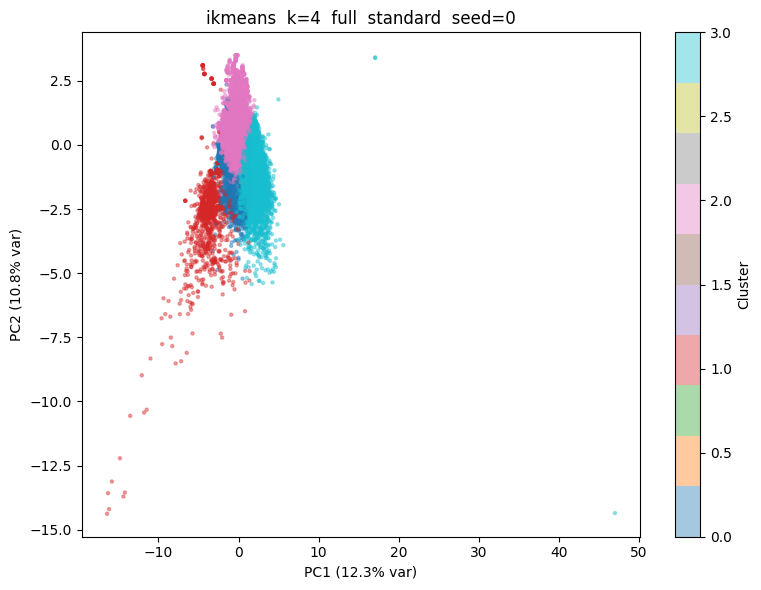

In [15]:
assert N_PCA_COMPONENTS >= 2, "N_PCA_COMPONENTS must be >= 2 for 2D scatter"
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap="tab10", alpha=0.4, s=5
)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"{ALGORITHM}  k={K}  {FEATURE_SET}  {SCALER}  seed={SEED}")
plt.tight_layout()
plt.show()

## 2 — Multi-Config Comparison

Define any set of configs in `CONFIGS`, run the cell below.

> **Note:** PCA axes are fit independently per config. Configs sharing the same `feature_set` have comparable axes, configs with different `feature_set` values do not.

In [4]:
# Load data once (shared across all configs in CONFIGS)
df_base = pd.read_csv(DATA_PATH)
if SUBSAMPLE_PATH is not None:
    _idx = load_subsample_indices(SUBSAMPLE_PATH)
    df_base = df_base.iloc[_idx].reset_index(drop=True)
print(f"Base dataset: {df_base.shape}")

CONFIGS = [
    {"algorithm": "kmeans", "k": 3, "seed": 0, "feature_set": "full",           "scaler": "standard"},
    {"algorithm": "kmeans", "k": 4, "seed": 0, "feature_set": "full",           "scaler": "standard"},
    {"algorithm": "kmeans", "k": 5, "seed": 0, "feature_set": "full",           "scaler": "standard"},
    {"algorithm": "kmeans", "k": 4, "seed": 0, "feature_set": "no_value_block", "scaler": "standard"},
    {"algorithm": "gmm",    "k": 4, "seed": 0, "feature_set": "full",           "scaler": "standard"},
    {"algorithm": "kmeans", "k": 4, "seed": 0, "feature_set": "full",           "scaler": "robust"},
]

Base dataset: (30000, 32)


In [5]:
_results = []
for cfg in CONFIGS:
    X_c, _ = preprocess_data(df_base, feature_set=cfg["feature_set"], scaler=cfg["scaler"])
    labels_c, _ = fit_predict(X_c, cfg["k"], cfg["seed"], cfg["algorithm"])
    scores_c = evaluate_clustering(X_c, labels_c)
    label = f"{cfg['algorithm']} k={cfg['k']} | {cfg['feature_set']} | {cfg['scaler']}"
    _results.append({"label": label, "cfg": cfg, "X": X_c, "labels": labels_c, **scores_c})
    print(f"✓ {label}")

✓ kmeans k=3 | full | standard
✓ kmeans k=4 | full | standard
✓ kmeans k=5 | full | standard
✓ kmeans k=4 | no_value_block | standard
✓ gmm k=4 | full | standard
✓ kmeans k=4 | full | robust


In [6]:
scores_df = pd.DataFrame([
    {
        "config": r["label"],
        "silhouette ↑": round(r["silhouette"], 4),
        "davies_bouldin ↓": round(r["davies_bouldin"], 4),
        "calinski_harabasz ↑": round(r["calinski_harabasz"], 4),
    }
    for r in _results
]).set_index("config")

display(scores_df)

,silhouette ↑,davies_bouldin ↓,calinski_harabasz ↑
config,,,
kmeans k=3 | full | standard,0.1295,2.3544,2707.7896
kmeans k=4 | full | standard,0.1034,1.9295,2700.5982
kmeans k=5 | full | standard,0.0998,1.8648,2759.1703
kmeans k=4 | no_value_block | standard,0.1190,1.8442,3542.7326
gmm k=4 | full | standard,0.1863,3.0299,1233.0279
kmeans k=4 | full | robust,0.1273,1.5076,5071.4777


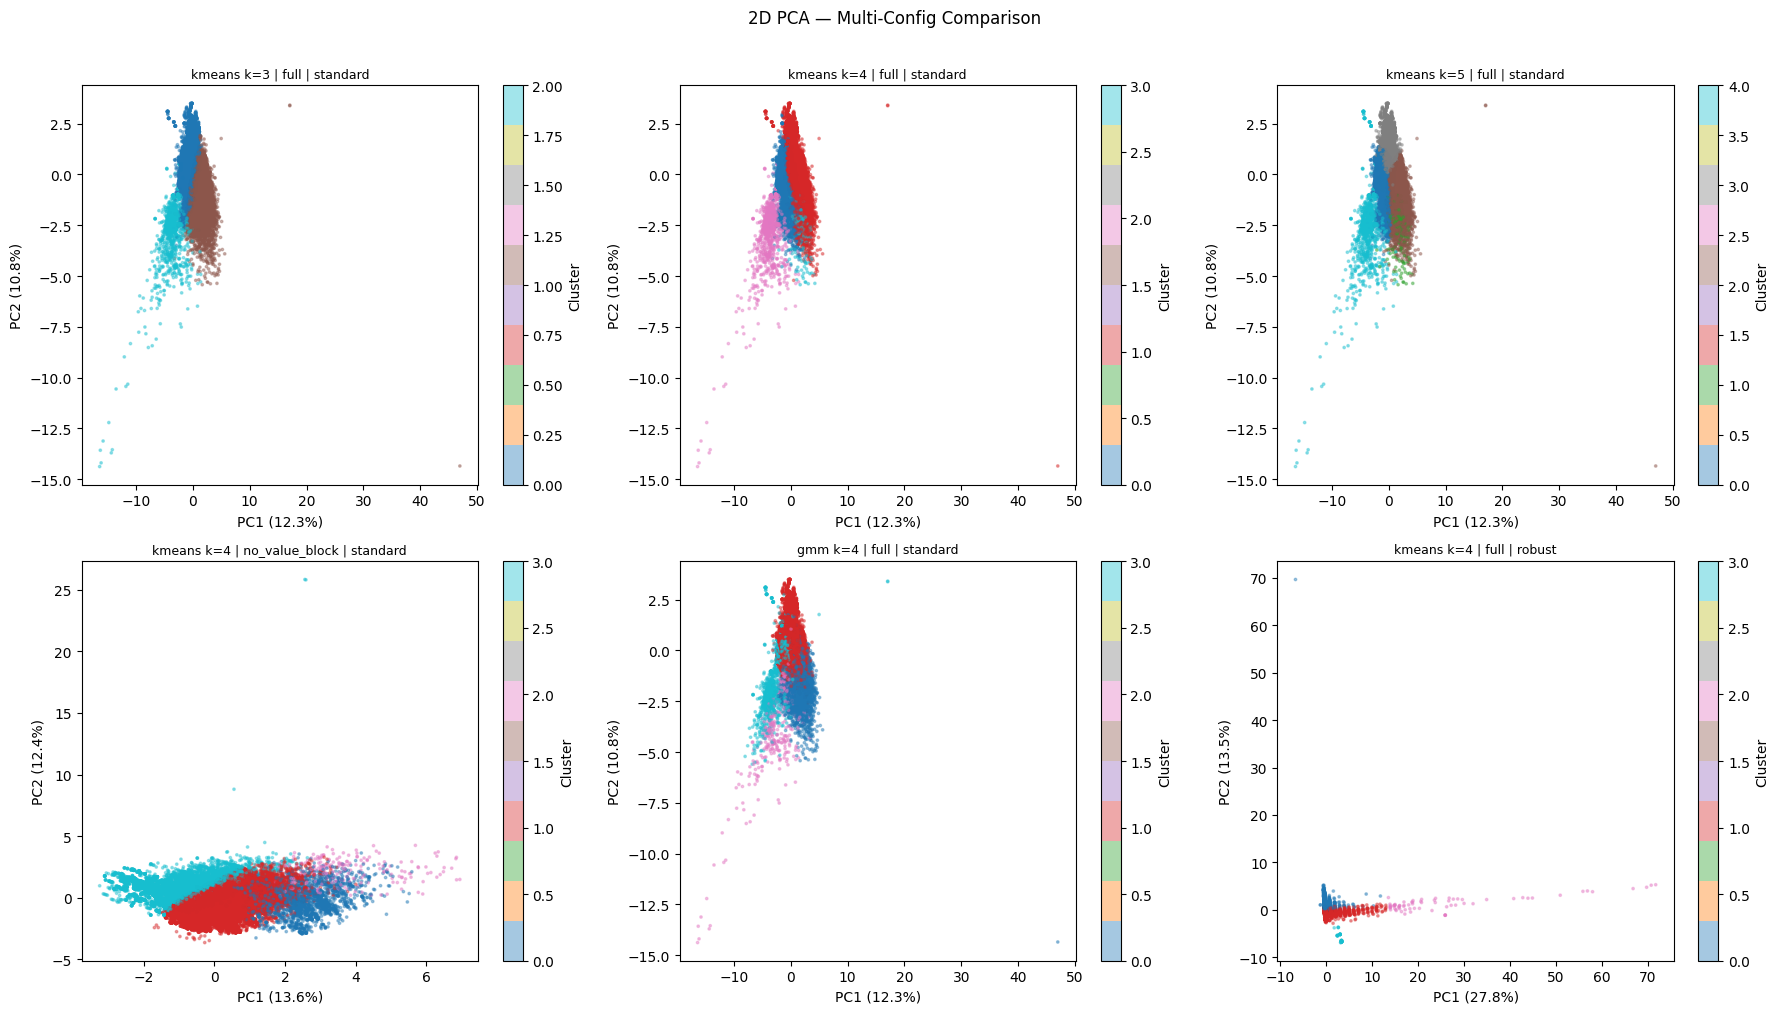

In [7]:
_n = len(_results)
_ncols = min(_n, 3)
_nrows = (_n + _ncols - 1) // _ncols

fig2d, axes2d = plt.subplots(_nrows, _ncols, figsize=(6 * _ncols, 5 * _nrows), squeeze=False)
axes_flat = axes2d.flatten()

for i, r in enumerate(_results):
    pca2 = PCA(n_components=2, random_state=0)
    X_2d = pca2.fit_transform(r["X"])
    ax = axes_flat[i]
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=r["labels"], cmap="tab10", alpha=0.4, s=3)
    plt.colorbar(sc, ax=ax, label="Cluster")
    ax.set_title(r["label"], fontsize=9)
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("2D PCA — Multi-Config Comparison", y=1.01)
plt.tight_layout()
plt.show()

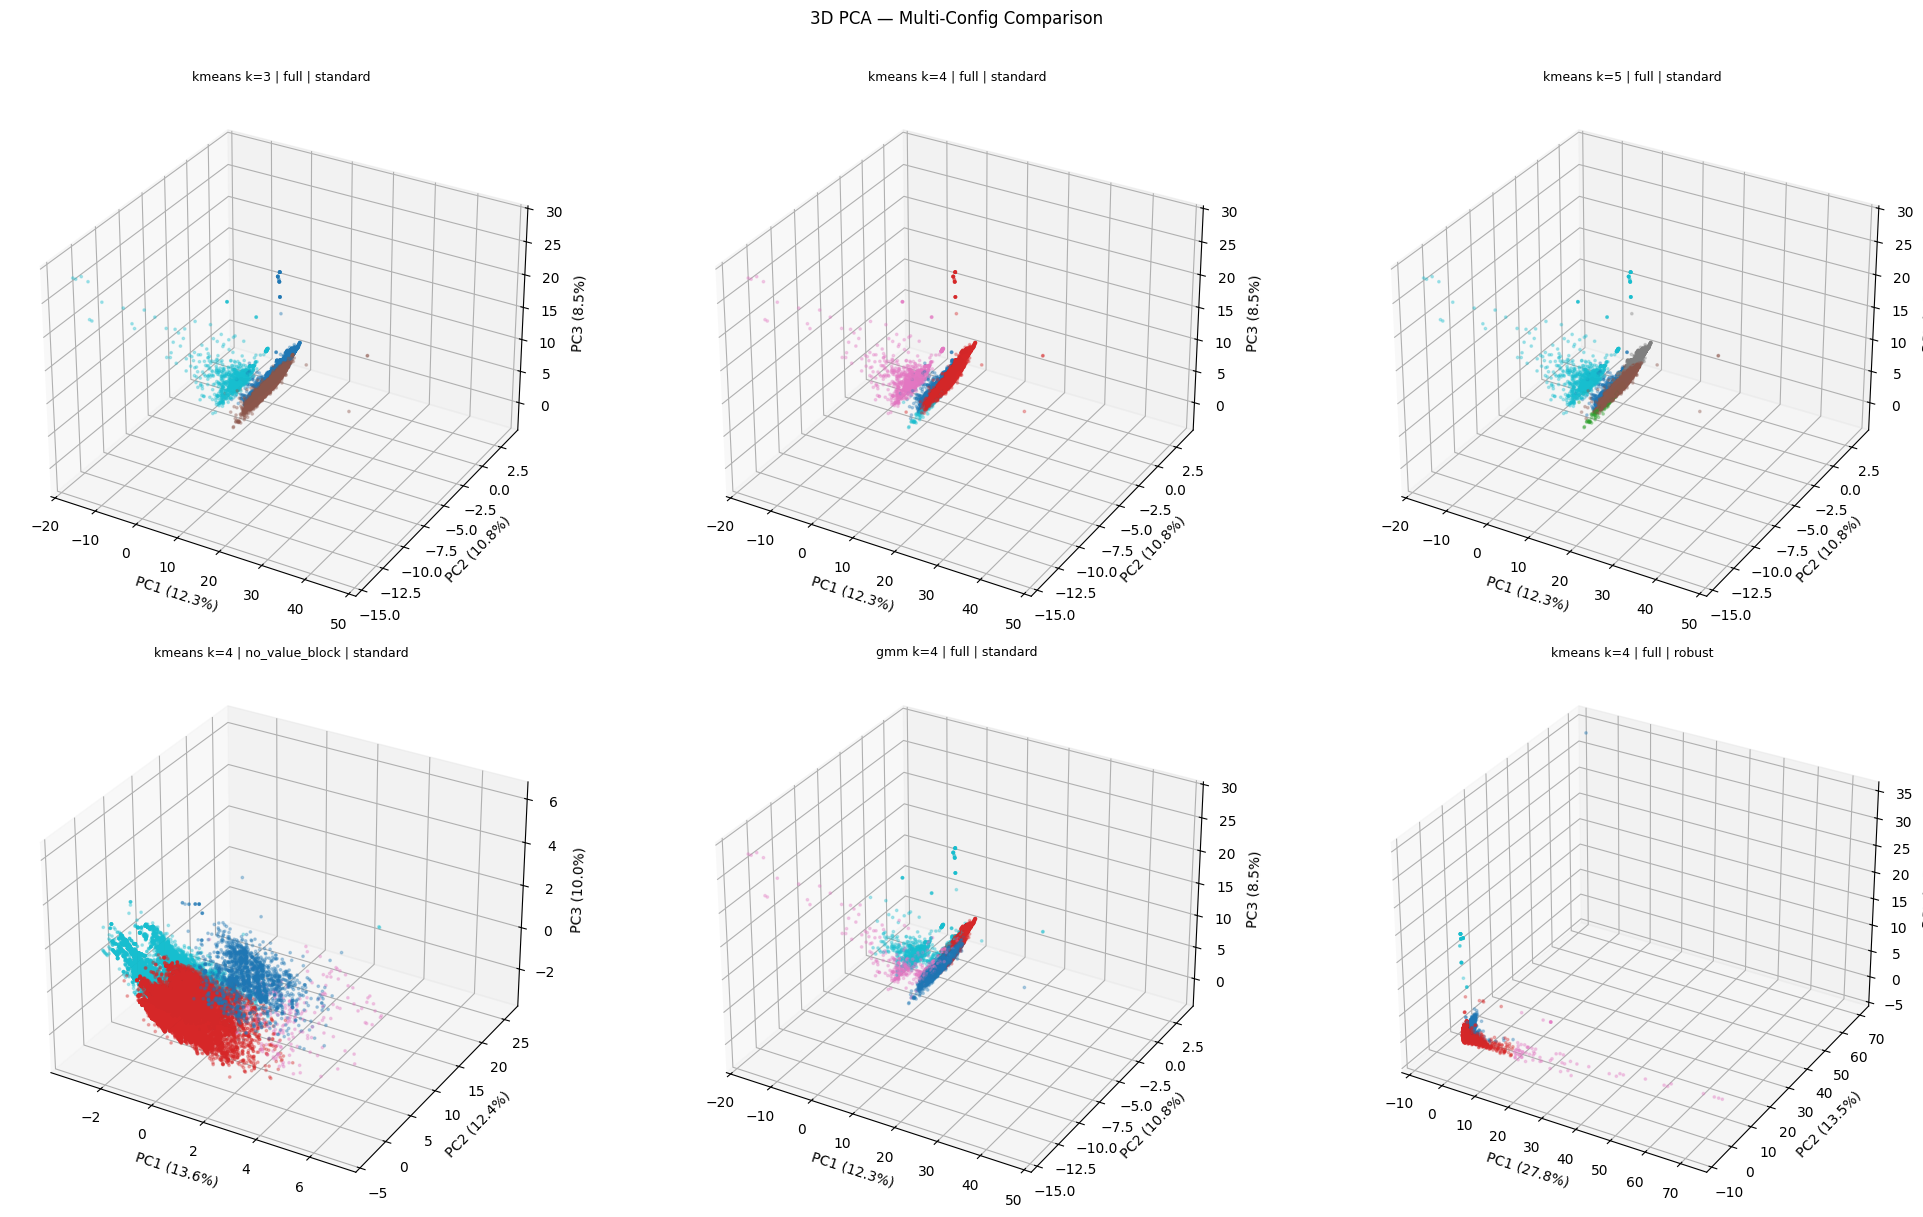

In [9]:
_n = len(_results)
_ncols = min(_n, 3)
_nrows = (_n + _ncols - 1) // _ncols

fig3d = plt.figure(figsize=(7 * _ncols, 6 * _nrows))
for i, r in enumerate(_results):
    pca3 = PCA(n_components=3, random_state=0)
    X_3d = pca3.fit_transform(r["X"])
    ax3 = fig3d.add_subplot(_nrows, _ncols, i + 1, projection="3d")
    ax3.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                c=r["labels"], cmap="tab10", alpha=0.3, s=3)
    ax3.set_title(r["label"], fontsize=9)
    ax3.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})")
    ax3.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})")
    ax3.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2]:.1%})")

plt.suptitle("3D PCA — Multi-Config Comparison", y=1.01)
plt.tight_layout()
plt.show()